In [21]:
import pandas as pd
import sys, importlib
import tcrempnet_utils as utils
importlib.reload(utils)
print('utils loaded; available:', len([n for n in dir(utils) if callable(getattr(utils, n, None))]))

import sys
sys.path.append('/home/evlasova/mirpy')
from mir.common.clonotype_dataset import ClonotypeDataset
from mir.common.clonotype import ClonotypeAA
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

utils loaded; available: 51


In [9]:
vdjdb_init = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt', sep='\t')
vdjdb_init= vdjdb_init[vdjdb_init['antigen.epitope'].str.startswith('YLQ')]
vdjdb_init

/scratch/ipykernel_3139148/1237304045.py:1: DtypeWarning: Columns (5,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  vdjdb_init = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/vdjdb_full_filtered.txt', sep='\t')


,cdr3.alpha,v.alpha,j.alpha,cdr3.beta,v.beta,d.beta,j.beta,species,mhc.a,mhc.b,...,meta.replica.id,meta.clone.id,meta.epitope.id,meta.tissue,meta.donor.MHC,meta.donor.MHC.method,meta.structure.id,cdr3fix.alpha,cdr3fix.beta,vdjdb.score
3863,CVVNSPSGNTPLVF,TRAV12-1*01,TRAJ29*01,CSARDEKATNTGELFF,TRBV20-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,NaN,PBMC,NaN,NaN,NaN,"{'cdr3': 'CVVNSPSGNTPLVF', 'cdr3_old': 'CVVNSP...","{'cdr3': 'CSARDEKATNTGELFF', 'cdr3_old': 'CSAR...",0
3864,CVVNRDNDMRF,TRAV12-1*01,TRAJ43*01,CASMEENTGELFF,TRBV5-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,NaN,PBMC,NaN,NaN,NaN,"{'cdr3': 'CVVNRDNDMRF', 'cdr3_old': 'CVVNRDNDM...","{'cdr3': 'CASMEENTGELFF', 'cdr3_old': 'CASMEEN...",0
3865,CVVNNGDKLIF,TRAV12-1*01,TRAJ34*01,CASSPGTTLAKNIQYF,TRBV7-6*01,NaN,TRBJ2-4*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,NaN,PBMC,NaN,NaN,NaN,"{'cdr3': 'CVVNNGDKLIF', 'cdr3_old': 'CVVNNGDKL...","{'cdr3': 'CASSPGTTLAKNIQYF', 'cdr3_old': 'CASS...",0
3866,CVVNGEDDMRF,TRAV12-1*01,TRAJ43*01,CASIRDHNTGELFF,TRBV5-4*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,NaN,PBMC,NaN,NaN,NaN,"{'cdr3': 'CVVNGEDDMRF', 'cdr3_old': 'CVVNGEDDM...","{'cdr3': 'CASIRDHNTGELFF', 'cdr3_old': 'CASIRD...",0
3867,CVVNGLGDDMRF,TRAV12-1*01,TRAJ43*01,CATQTANTGELFF,TRBV24-1*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,...,NaN,NaN,NaN,PBMC,NaN,NaN,NaN,"{'cdr3': 'CVVNGLGDDMRF', 'cdr3_old': 'CVVNGLGD...","{'cdr3': 'CATQTANTGELFF', 'cdr3_old': 'CATQTAN...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102976,NaN,NaN,NaN,CATTELDTGELFF,TRBV15*01,NaN,TRBJ2-2*01,HomoSapiens,HLA-A*02,B2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'cdr3': 'CATTELDTGELFF', 'cdr3_old': 'CATTELD...",1
102977,NaN,NaN,NaN,CASRGLAEMNTGELFF,TRBV2*01,TRBD2,TRBJ2-2*01,HomoSapiens,HLA-A*02,B2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'cdr3': 'CASRGLAEMNTGELFF', 'cdr3_old': 'CASR...",0
102978,NaN,NaN,NaN,CSVKNGTRWTQYF,TRBV20-1*01,TRBD2,TRBJ2-5*01,HomoSapiens,HLA-A*02,B2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'cdr3': 'CSVKNGTRWTQYF', 'cdr3_old': 'CSVKNGT...",0
102979,NaN,NaN,NaN,CASSPPAWSGEQYF,TRBV11-2*01,TRBD2,TRBJ2-7*01,HomoSapiens,HLA-A*02,B2M,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'cdr3': 'CASSPPAWSGEQYF', 'cdr3_old': 'CASSPP...",0


In [15]:
tcrvdb = pd.read_csv('../../data/01_05_2025_TCRvdb.csv').drop(columns=['Unnamed: 0']).dropna(subset=['padj'])
tcrvdb['valid'] = tcrvdb.padj < 10**-5 
tcrvdb = tcrvdb[tcrvdb.epitope_aa.str.startswith('YLQ')]
tcrvdb = tcrvdb[['cdr3_alpha_aa', 'cdr3_beta_aa', 'TRAV', 'TRAJ',
       'TRBV', 'TRBJ', 'TRBD', 'valid']]
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid
0,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,True
1,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,False
2,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,False
3,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,False
4,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,True
...,...,...,...,...,...,...,...,...
435,CALSEASTGNQFYF,CSASRGGALYNEQFF,TRAV19,TRAJ49,TRBV20-1,TRBJ2-1,TRBD2,False
436,CVVNNNNDMRF,CARGDANTGELFF,TRAV12-1,TRAJ43,TRBV12-3,TRBJ2-2,NaN,True
437,CAGQRGGADGLTF,CASSLAAAYEQYF,TRAV35,TRAJ45,TRBV13,TRBJ2-7,TRBD1,False
438,CLVGENFNKFYF,CASSLGQSLEQYF,TRAV4,TRAJ21,TRBV5-1,TRBJ2-7,NaN,False


In [3]:
motifs = pd.read_csv('/projects/immunestatus/vdjdb/vdjdb-2025-07-30/cluster_members.txt', sep='\t')
motifs

,species,antigen.epitope,antigen.gene,antigen.species,mhc.a,mhc.b,mhc.class,gene,cdr3aa,x,y,cid,csz,v.segm,j.segm,v.end,j.start,v.segm.repr,j.segm.repr
0,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLSGDDYNEQFF,102.447143,32.107434,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
1,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDDYNEQFF,36.799698,2.795705,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
2,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDNYNEQFF,3.568838,-52.141266,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,9,TRBV27*01,TRBJ2-1*01
3,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLAGDSYNEQFF,-36.541775,-2.006452,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
4,HomoSapiens,ALSKGVHFV,ORF3,SARS-CoV-2,HLA-A*02:01,B2M,MHCI,TRB,CASSLVGDSYNEQFF,-105.450820,18.494963,H.B.ALSKGVHFV.1,5,TRBV27*01,TRBJ2-1*01,5,8,TRBV27*01,TRBJ2-1*01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35563,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CAASENYNQGKLIF,308.410316,128.603566,M.A.TVYGFCLL.2,12,"TRAV7-4*01,TRAV7D-4*01",TRAJ23*01,5,5,TRAV12D-1*01,TRAJ23*01
35564,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIMNYNQGKLIF,187.064152,-192.603423,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35565,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALIPNYNQGKLIF,267.595691,-180.697136,M.A.TVYGFCLL.2,12,TRAV12D-1*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01
35566,MusMusculus,TVYGFCLL,m139,MCMV,H-2Kb,B2M,MHCI,TRA,CALRENYNQGKLIF,242.143769,-43.271264,M.A.TVYGFCLL.2,12,TRAV12-3*01,TRAJ23*01,3,5,TRAV12D-1*01,TRAJ23*01


In [6]:
motifs = motifs[motifs['antigen.epitope'].str.startswith('YLQ')][['cdr3aa', 'v.segm', 'j.segm', 'antigen.epitope', 'gene']]

In [40]:
motifs['j.segm'].apply(lambda x: ',' in x).sum()

1

In [36]:
motifs['v.segm'].apply(lambda x: x.split('*')[0])

,cdr3aa,v.segm,j.segm,antigen.epitope,gene
33739,CVVNMETDKLIF,TRAV12-1*01,TRAJ34*01,YLQPRTFLL,TRA
33740,CVVNMENDMRF,TRAV12-1*01,TRAJ43*01,YLQPRTFLL,TRA
33741,CASQDTNTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL,TRB
33742,CASQEANTGELFF,"TRBV19*01,TRBV4-3*01",TRBJ2-2*01,YLQPRTFLL,TRB
33743,CASQELDTGELFF,TRBV2*01,TRBJ2-2*01,YLQPRTFLL,TRB
...,...,...,...,...,...
34297,CATTDLNTGELFF,TRBV15*01,TRBJ2-2*01,YLQPRTFLL,TRB
34298,CSARDALAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL,TRB
34299,CSARDDRALNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL,TRB
34300,CSARDDRAQNTGELFF,TRBV20-1*01,TRBJ2-2*01,YLQPRTFLL,TRB


In [39]:
df = motifs.copy()
def expand_comma_column(df, col):
    return (
        df.assign(**{col: df[col].str.split(r'\s*,\s*')})
          .explode(col)
          .assign(**{col: lambda x: x[col].str.strip()})
    )

# Последовательно разворачиваем оба столбца
df_expanded = expand_comma_column(df, 'v.segm')
df_expanded = expand_comma_column(df_expanded, 'j.segm')

# Убираем возможные пустые строки после разбиения
df_expanded = df_expanded[df_expanded['v.segm'].str.len() > 0]
df_expanded = df_expanded[df_expanded['j.segm'].str.len() > 0]

df_expanded = df_expanded.reset_index(drop=True)

print(df_expanded.shape)
print(df_expanded.head(12))

(599, 5)
           cdr3aa       v.segm      j.segm antigen.epitope gene
0    CVVNMETDKLIF  TRAV12-1*01   TRAJ34*01       YLQPRTFLL  TRA
1     CVVNMENDMRF  TRAV12-1*01   TRAJ43*01       YLQPRTFLL  TRA
2   CASQDTNTGELFF     TRBV2*01  TRBJ2-2*01       YLQPRTFLL  TRB
3   CASQEANTGELFF    TRBV19*01  TRBJ2-2*01       YLQPRTFLL  TRB
4   CASQEANTGELFF   TRBV4-3*01  TRBJ2-2*01       YLQPRTFLL  TRB
5   CASQELDTGELFF     TRBV2*01  TRBJ2-2*01       YLQPRTFLL  TRB
6     CVVNMFDDMRF  TRAV12-1*01   TRAJ43*01       YLQPRTFLL  TRA
7     CVVNMGDDMRF  TRAV12-1*01   TRAJ43*01       YLQPRTFLL  TRA
8     CVVNMLDDMRF  TRAV12-1*01   TRAJ43*01       YLQPRTFLL  TRA
9     CVVNMMDDMRF  TRAV12-1*01   TRAJ43*01       YLQPRTFLL  TRA
10    CVVNMNNDMRF  TRAV12-1*01   TRAJ43*01       YLQPRTFLL  TRA
11   CVVNMNNNDMRF  TRAV12-1*01   TRAJ43*01       YLQPRTFLL  TRA


In [42]:
df_expanded['v.segm'] = df_expanded['v.segm'].apply(lambda x: x.split('*')[0])
df_expanded['j.segm'] = df_expanded['j.segm'].apply(lambda x: x.split('*')[0])

In [43]:
motifs = df_expanded.copy()
motifs

,cdr3aa,v.segm,j.segm,antigen.epitope,gene
0,CVVNMETDKLIF,TRAV12-1,TRAJ34,YLQPRTFLL,TRA
1,CVVNMENDMRF,TRAV12-1,TRAJ43,YLQPRTFLL,TRA
2,CASQDTNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,TRB
3,CASQEANTGELFF,TRBV19,TRBJ2-2,YLQPRTFLL,TRB
4,CASQEANTGELFF,TRBV4-3,TRBJ2-2,YLQPRTFLL,TRB
...,...,...,...,...,...
594,CATTDLNTGELFF,TRBV15,TRBJ2-2,YLQPRTFLL,TRB
595,CSARDALAQNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,TRB
596,CSARDDRALNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,TRB
597,CSARDDRAQNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,TRB


In [44]:
motifs[motifs.gene == 'TRA']

,cdr3aa,v.segm,j.segm,antigen.epitope,gene
0,CVVNMETDKLIF,TRAV12-1,TRAJ34,YLQPRTFLL,TRA
1,CVVNMENDMRF,TRAV12-1,TRAJ43,YLQPRTFLL,TRA
6,CVVNMFDDMRF,TRAV12-1,TRAJ43,YLQPRTFLL,TRA
7,CVVNMGDDMRF,TRAV12-1,TRAJ43,YLQPRTFLL,TRA
8,CVVNMLDDMRF,TRAV12-1,TRAJ43,YLQPRTFLL,TRA
...,...,...,...,...,...
249,CVVNLPSGNTPLVF,TRAV12-1,TRAJ29,YLQPRTFLL,TRA
250,CVVNMATDKLIF,TRAV12-1,TRAJ34,YLQPRTFLL,TRA
251,CVVNMDDKIIF,TRAV12-1,TRAJ30,YLQPRTFLL,TRA
252,CVVNMDTDKLIF,TRAV12-1,TRAJ34,YLQPRTFLL,TRA


In [45]:
motifs[motifs.gene == 'TRB']

,cdr3aa,v.segm,j.segm,antigen.epitope,gene
2,CASQDTNTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,TRB
3,CASQEANTGELFF,TRBV19,TRBJ2-2,YLQPRTFLL,TRB
4,CASQEANTGELFF,TRBV4-3,TRBJ2-2,YLQPRTFLL,TRB
5,CASQELDTGELFF,TRBV2,TRBJ2-2,YLQPRTFLL,TRB
90,CASGTLNTGELFF,TRBV7-8,TRBJ2-2,YLQPRTFLL,TRB
...,...,...,...,...,...
594,CATTDLNTGELFF,TRBV15,TRBJ2-2,YLQPRTFLL,TRB
595,CSARDALAQNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,TRB
596,CSARDDRALNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,TRB
597,CSARDDRAQNTGELFF,TRBV20-1,TRBJ2-2,YLQPRTFLL,TRB


In [46]:
tcrvdb['TRA_tcrnet'] = tcrvdb['cdr3_alpha_aa'].isin(motifs[motifs.gene == 'TRA'].cdr3aa)
tcrvdb['TRB_tcrnet'] = tcrvdb['cdr3_beta_aa'].isin(motifs[motifs.gene == 'TRB'].cdr3aa)

In [47]:
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid,TRA_tcrnet,TRB_tcrnet,tra_and_trb,tra_or_trb,TRA_with_seg,TRB_with_seg,TRA_tcrnet_with_seg,TRB_tcrnet_with_seg
0,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,True,True,False,False,True,CVVNIDTDKLIFTRAV12-1TRAJ34,CATGGDHNTGELFFTRBV2TRBJ2-2,False,False
1,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,False,False,False,False,False,CAEILDFGNEKLTFTRAV5TRAJ48,CSARDPSGVKLFFTRBV20-1TRBJ1-4,False,False
2,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,False,False,False,False,False,CAAMNYGGSQGNLIFTRAV35TRAJ42,CASSYRGTGLNEQFFTRBV6-2TRBJ2-1,False,False
3,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,False,False,False,False,False,CAVKDTDKLIFTRAV21TRAJ34,CASSLAGSSYNSPLHFTRBV7-8TRBJ1-6,False,False
4,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,True,True,False,False,True,CVVNRNNDMRFTRAV12-1TRAJ43,CATQSDPNTGELFFTRBV2TRBJ2-2,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,CALSEASTGNQFYF,CSASRGGALYNEQFF,TRAV19,TRAJ49,TRBV20-1,TRBJ2-1,TRBD2,False,False,False,False,False,CALSEASTGNQFYFTRAV19TRAJ49,CSASRGGALYNEQFFTRBV20-1TRBJ2-1,False,False
436,CVVNNNNDMRF,CARGDANTGELFF,TRAV12-1,TRAJ43,TRBV12-3,TRBJ2-2,NaN,True,True,True,True,True,CVVNNNNDMRFTRAV12-1TRAJ43,CARGDANTGELFFTRBV12-3TRBJ2-2,False,False
437,CAGQRGGADGLTF,CASSLAAAYEQYF,TRAV35,TRAJ45,TRBV13,TRBJ2-7,TRBD1,False,False,False,False,False,CAGQRGGADGLTFTRAV35TRAJ45,CASSLAAAYEQYFTRBV13TRBJ2-7,False,False
438,CLVGENFNKFYF,CASSLGQSLEQYF,TRAV4,TRAJ21,TRBV5-1,TRBJ2-7,NaN,False,False,False,False,False,CLVGENFNKFYFTRAV4TRAJ21,CASSLGQSLEQYFTRBV5-1TRBJ2-7,False,False


In [48]:
tcrvdb['tra_and_trb'] = tcrvdb.TRA_tcrnet & tcrvdb.TRB_tcrnet
tcrvdb['tra_or_trb'] = tcrvdb.TRA_tcrnet | tcrvdb.TRB_tcrnet

In [49]:
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid,TRA_tcrnet,TRB_tcrnet,tra_and_trb,tra_or_trb,TRA_with_seg,TRB_with_seg,TRA_tcrnet_with_seg,TRB_tcrnet_with_seg
0,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,True,True,False,False,True,CVVNIDTDKLIFTRAV12-1TRAJ34,CATGGDHNTGELFFTRBV2TRBJ2-2,False,False
1,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,False,False,False,False,False,CAEILDFGNEKLTFTRAV5TRAJ48,CSARDPSGVKLFFTRBV20-1TRBJ1-4,False,False
2,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,False,False,False,False,False,CAAMNYGGSQGNLIFTRAV35TRAJ42,CASSYRGTGLNEQFFTRBV6-2TRBJ2-1,False,False
3,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,False,False,False,False,False,CAVKDTDKLIFTRAV21TRAJ34,CASSLAGSSYNSPLHFTRBV7-8TRBJ1-6,False,False
4,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,True,True,False,False,True,CVVNRNNDMRFTRAV12-1TRAJ43,CATQSDPNTGELFFTRBV2TRBJ2-2,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,CALSEASTGNQFYF,CSASRGGALYNEQFF,TRAV19,TRAJ49,TRBV20-1,TRBJ2-1,TRBD2,False,False,False,False,False,CALSEASTGNQFYFTRAV19TRAJ49,CSASRGGALYNEQFFTRBV20-1TRBJ2-1,False,False
436,CVVNNNNDMRF,CARGDANTGELFF,TRAV12-1,TRAJ43,TRBV12-3,TRBJ2-2,NaN,True,True,True,True,True,CVVNNNNDMRFTRAV12-1TRAJ43,CARGDANTGELFFTRBV12-3TRBJ2-2,False,False
437,CAGQRGGADGLTF,CASSLAAAYEQYF,TRAV35,TRAJ45,TRBV13,TRBJ2-7,TRBD1,False,False,False,False,False,CAGQRGGADGLTFTRAV35TRAJ45,CASSLAAAYEQYFTRBV13TRBJ2-7,False,False
438,CLVGENFNKFYF,CASSLGQSLEQYF,TRAV4,TRAJ21,TRBV5-1,TRBJ2-7,NaN,False,False,False,False,False,CLVGENFNKFYFTRAV4TRAJ21,CASSLGQSLEQYFTRBV5-1TRBJ2-7,False,False


In [50]:
tcrvdb['TRA_tcrnet'] = tcrvdb['cdr3_alpha_aa'].isin(motifs[motifs.gene == 'TRA'].cdr3aa)
tcrvdb['TRB_tcrnet'] = tcrvdb['cdr3_beta_aa'].isin(motifs[motifs.gene == 'TRB'].cdr3aa)

In [51]:
alpha_motifs = motifs[motifs.gene == 'TRA']
beta_motifs = motifs[motifs.gene == 'TRB']

alpha_seqs_with_seg = alpha_motifs['cdr3aa'] + alpha_motifs['v.segm'] + alpha_motifs['j.segm']
beta_seqs_with_seg = beta_motifs['cdr3aa'] + beta_motifs['v.segm'] + beta_motifs['j.segm']


In [52]:
tcrvdb['TRA_with_seg'] = tcrvdb['cdr3_alpha_aa'] + tcrvdb['TRAV'] + tcrvdb['TRAJ']
tcrvdb['TRB_with_seg'] = tcrvdb['cdr3_beta_aa'] + tcrvdb['TRBV'] + tcrvdb['TRBJ']
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid,TRA_tcrnet,TRB_tcrnet,tra_and_trb,tra_or_trb,TRA_with_seg,TRB_with_seg,TRA_tcrnet_with_seg,TRB_tcrnet_with_seg
0,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,True,True,False,False,True,CVVNIDTDKLIFTRAV12-1TRAJ34,CATGGDHNTGELFFTRBV2TRBJ2-2,False,False
1,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,False,False,False,False,False,CAEILDFGNEKLTFTRAV5TRAJ48,CSARDPSGVKLFFTRBV20-1TRBJ1-4,False,False
2,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,False,False,False,False,False,CAAMNYGGSQGNLIFTRAV35TRAJ42,CASSYRGTGLNEQFFTRBV6-2TRBJ2-1,False,False
3,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,False,False,False,False,False,CAVKDTDKLIFTRAV21TRAJ34,CASSLAGSSYNSPLHFTRBV7-8TRBJ1-6,False,False
4,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,True,True,False,False,True,CVVNRNNDMRFTRAV12-1TRAJ43,CATQSDPNTGELFFTRBV2TRBJ2-2,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,CALSEASTGNQFYF,CSASRGGALYNEQFF,TRAV19,TRAJ49,TRBV20-1,TRBJ2-1,TRBD2,False,False,False,False,False,CALSEASTGNQFYFTRAV19TRAJ49,CSASRGGALYNEQFFTRBV20-1TRBJ2-1,False,False
436,CVVNNNNDMRF,CARGDANTGELFF,TRAV12-1,TRAJ43,TRBV12-3,TRBJ2-2,NaN,True,True,True,True,True,CVVNNNNDMRFTRAV12-1TRAJ43,CARGDANTGELFFTRBV12-3TRBJ2-2,False,False
437,CAGQRGGADGLTF,CASSLAAAYEQYF,TRAV35,TRAJ45,TRBV13,TRBJ2-7,TRBD1,False,False,False,False,False,CAGQRGGADGLTFTRAV35TRAJ45,CASSLAAAYEQYFTRBV13TRBJ2-7,False,False
438,CLVGENFNKFYF,CASSLGQSLEQYF,TRAV4,TRAJ21,TRBV5-1,TRBJ2-7,NaN,False,False,False,False,False,CLVGENFNKFYFTRAV4TRAJ21,CASSLGQSLEQYFTRBV5-1TRBJ2-7,False,False


In [53]:
tcrvdb['TRA_tcrnet_with_seg'] = tcrvdb['TRA_with_seg'].isin(alpha_seqs_with_seg)
tcrvdb['TRB_tcrnet_with_seg'] = tcrvdb['TRB_with_seg'].isin(beta_seqs_with_seg)

In [54]:
tcrvdb

,cdr3_alpha_aa,cdr3_beta_aa,TRAV,TRAJ,TRBV,TRBJ,TRBD,valid,TRA_tcrnet,TRB_tcrnet,tra_and_trb,tra_or_trb,TRA_with_seg,TRB_with_seg,TRA_tcrnet_with_seg,TRB_tcrnet_with_seg
0,CVVNIDTDKLIF,CATGGDHNTGELFF,TRAV12-1,TRAJ34,TRBV2,TRBJ2-2,NaN,True,True,False,False,True,CVVNIDTDKLIFTRAV12-1TRAJ34,CATGGDHNTGELFFTRBV2TRBJ2-2,True,False
1,CAEILDFGNEKLTF,CSARDPSGVKLFF,TRAV5,TRAJ48,TRBV20-1,TRBJ1-4,NaN,False,False,False,False,False,CAEILDFGNEKLTFTRAV5TRAJ48,CSARDPSGVKLFFTRBV20-1TRBJ1-4,False,False
2,CAAMNYGGSQGNLIF,CASSYRGTGLNEQFF,TRAV35,TRAJ42,TRBV6-2,TRBJ2-1,NaN,False,False,False,False,False,CAAMNYGGSQGNLIFTRAV35TRAJ42,CASSYRGTGLNEQFFTRBV6-2TRBJ2-1,False,False
3,CAVKDTDKLIF,CASSLAGSSYNSPLHF,TRAV21,TRAJ34,TRBV7-8,TRBJ1-6,NaN,False,False,False,False,False,CAVKDTDKLIFTRAV21TRAJ34,CASSLAGSSYNSPLHFTRBV7-8TRBJ1-6,False,False
4,CVVNRNNDMRF,CATQSDPNTGELFF,TRAV12-1,TRAJ43,TRBV2,TRBJ2-2,NaN,True,True,False,False,True,CVVNRNNDMRFTRAV12-1TRAJ43,CATQSDPNTGELFFTRBV2TRBJ2-2,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,CALSEASTGNQFYF,CSASRGGALYNEQFF,TRAV19,TRAJ49,TRBV20-1,TRBJ2-1,TRBD2,False,False,False,False,False,CALSEASTGNQFYFTRAV19TRAJ49,CSASRGGALYNEQFFTRBV20-1TRBJ2-1,False,False
436,CVVNNNNDMRF,CARGDANTGELFF,TRAV12-1,TRAJ43,TRBV12-3,TRBJ2-2,NaN,True,True,True,True,True,CVVNNNNDMRFTRAV12-1TRAJ43,CARGDANTGELFFTRBV12-3TRBJ2-2,True,True
437,CAGQRGGADGLTF,CASSLAAAYEQYF,TRAV35,TRAJ45,TRBV13,TRBJ2-7,TRBD1,False,False,False,False,False,CAGQRGGADGLTFTRAV35TRAJ45,CASSLAAAYEQYFTRBV13TRBJ2-7,False,False
438,CLVGENFNKFYF,CASSLGQSLEQYF,TRAV4,TRAJ21,TRBV5-1,TRBJ2-7,NaN,False,False,False,False,False,CLVGENFNKFYFTRAV4TRAJ21,CASSLGQSLEQYFTRBV5-1TRBJ2-7,False,False


In [61]:
tcrvdb['tra_and_trb_vj'] = tcrvdb.TRA_tcrnet_with_seg & tcrvdb.TRB_tcrnet_with_seg
tcrvdb['tra_or_trb_vj'] = tcrvdb.TRA_tcrnet_with_seg | tcrvdb.TRB_tcrnet_with_seg

In [55]:
confusion_matrix(tcrvdb.valid, tcrvdb.tra_or_trb)

array([[194,  55],
       [ 21, 151]])

In [56]:
confusion_matrix(tcrvdb.valid, tcrvdb.tra_and_trb)

array([[242,   7],
       [ 89,  83]])

In [57]:
confusion_matrix(tcrvdb.valid, tcrvdb.TRB_tcrnet)

array([[206,  43],
       [ 57, 115]])

In [58]:
confusion_matrix(tcrvdb.valid, tcrvdb.TRA_tcrnet)

array([[230,  19],
       [ 53, 119]])

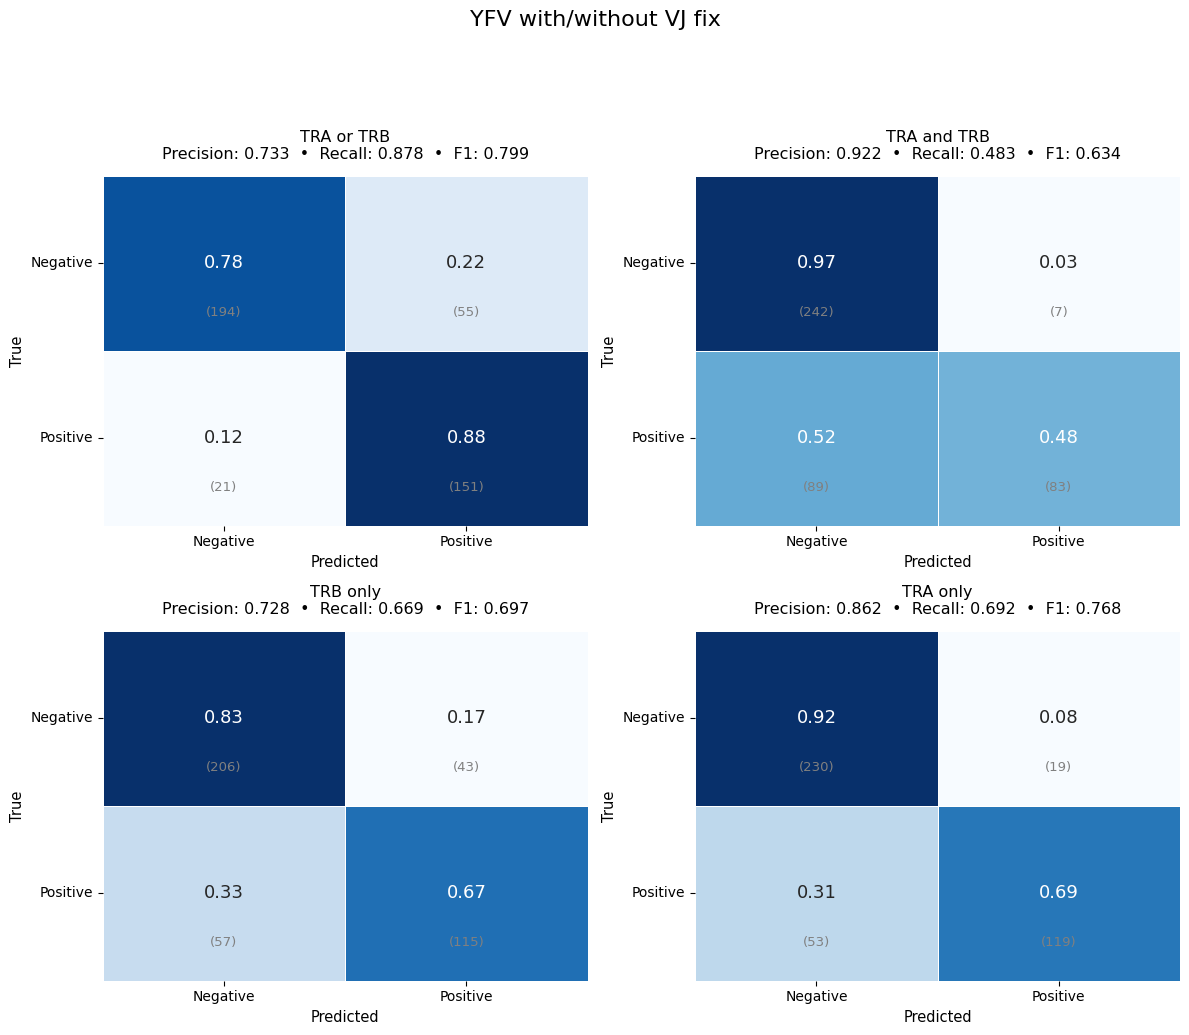

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Предполагаем, что у вас есть:
# tcrvdb.valid           → y_true
# tcrvdb.tra_or_trb      → y_pred 1
# и т.д.

# Вычисляем матрицы
cm1 = confusion_matrix(tcrvdb.valid, tcrvdb.tra_or_trb)
cm2 = confusion_matrix(tcrvdb.valid, tcrvdb.tra_and_trb)
cm3 = confusion_matrix(tcrvdb.valid, tcrvdb.TRB_tcrnet)
cm4 = confusion_matrix(tcrvdb.valid, tcrvdb.TRA_tcrnet)

model_names = [
    "TRA or TRB",
    "TRA and TRB",
    "TRB only",
    "TRA only"
]

cms = [cm1, cm2, cm3, cm4]
y_trues  = [tcrvdb.valid] * 4
y_preds  = [
    tcrvdb.tra_or_trb,
    tcrvdb.tra_and_trb,
    tcrvdb.TRB_tcrnet,
    tcrvdb.TRA_tcrnet
]

# ────────────────────────────────────────────────
# Основной график 2×2
# ────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("YFV with/without VJ fix", fontsize=16, y=1.03)

for ax, cm, y_true, y_pred, title in zip(axes.flat, cms, y_trues, y_preds, model_names):
    # Метрики (positive class = 1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=1, average='binary', zero_division=0
    )
    
    # Заголовок с метриками
    metrics_text = f"Precision: {precision:.3f}  •  Recall: {recall:.3f}  •  F1: {f1:.3f}"
    ax.set_title(f"{title}\n{metrics_text}", fontsize=11.5, pad=12)
    
    # Нормализованная матрица (по строкам = recall по классам)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Heatmap
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        ax=ax,
        linewidths=0.6,
        linecolor='white',
        annot_kws={"size": 13}
    )
    
    # Абсолютные значения мелким шрифтом
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            ax.text(j + 0.5, i + 0.78, f"({count})",
                    ha="center", va="center",
                    color="gray", fontsize=9.5)
    
    ax.set_xlabel("Predicted", fontsize=10.5)
    ax.set_ylabel("True", fontsize=10.5)
    
    # Подписи классов (если бинарная классификация)
    class_labels = ["Negative", "Positive"]
    ax.set_xticklabels(class_labels, fontsize=10)
    ax.set_yticklabels(class_labels, fontsize=10, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('results/YFV.pdf')
plt.show()

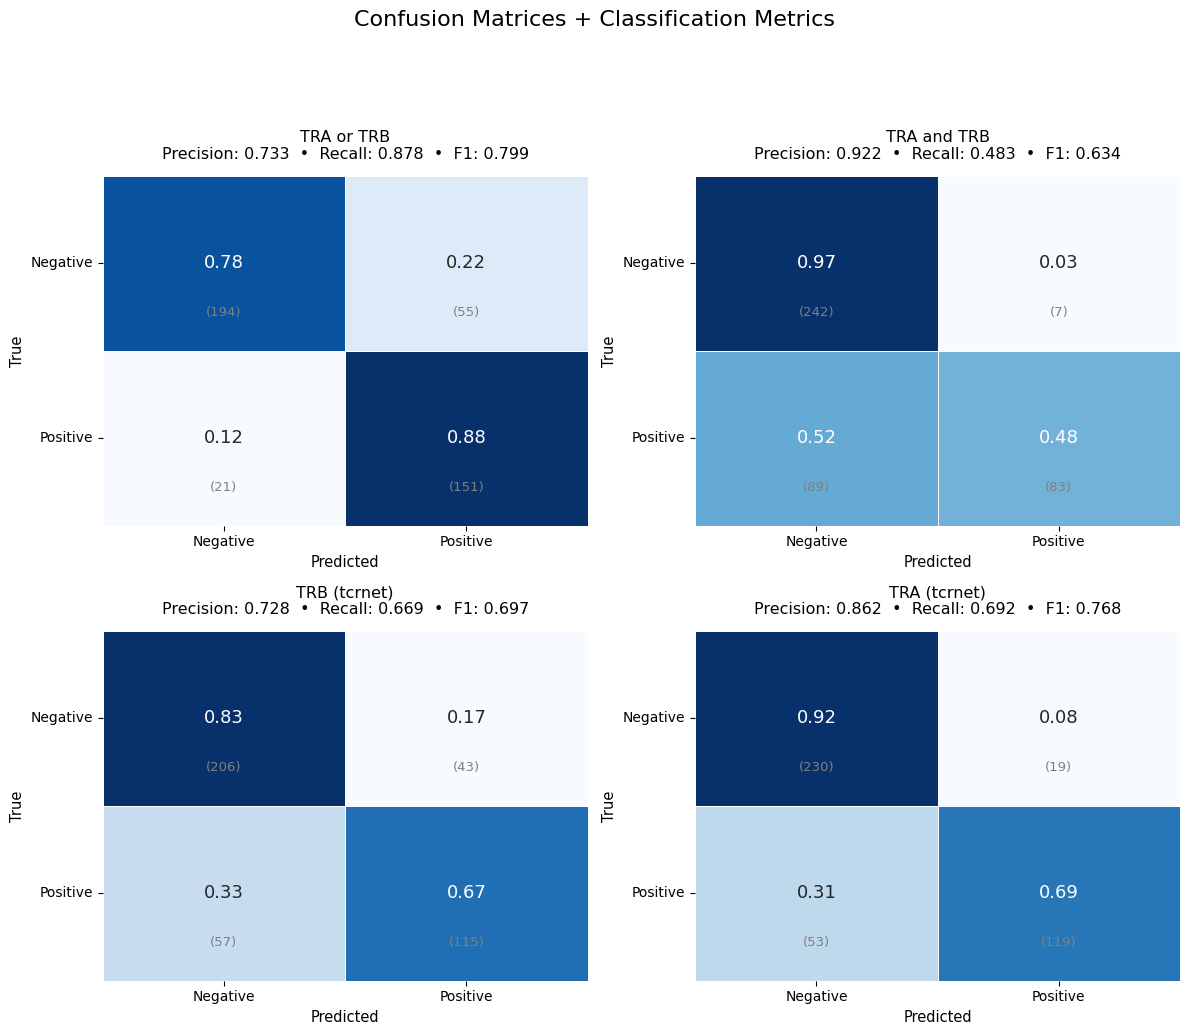

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Предполагаем, что у вас есть:
# tcrvdb.valid           → y_true
# tcrvdb.tra_or_trb      → y_pred 1
# и т.д.

# Вычисляем матрицы
cm1 = confusion_matrix(tcrvdb.valid, tcrvdb.tra_or_trb_vj)
cm2 = confusion_matrix(tcrvdb.valid, tcrvdb.tra_and_trb_vj)
cm3 = confusion_matrix(tcrvdb.valid, tcrvdb.TRB_tcrnet_with_seg)
cm4 = confusion_matrix(tcrvdb.valid, tcrvdb.TRA_tcrnet_with_seg)

model_names = [
    "TRA or TRB",
    "TRA and TRB",
    "TRB (tcrnet)",
    "TRA (tcrnet)"
]

cms = [cm1, cm2, cm3, cm4]
y_trues  = [tcrvdb.valid] * 4
y_preds  = [
    tcrvdb.tra_or_trb_vj,
    tcrvdb.tra_and_trb_vj,
    tcrvdb.TRB_tcrnet_with_seg,
    tcrvdb.TRA_tcrnet_with_seg
]

# ────────────────────────────────────────────────
# Основной график 2×2
# ────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices + Classification Metrics", fontsize=16, y=1.03)

for ax, cm, y_true, y_pred, title in zip(axes.flat, cms, y_trues, y_preds, model_names):
    # Метрики (positive class = 1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, pos_label=1, average='binary', zero_division=0
    )
    
    # Заголовок с метриками
    metrics_text = f"Precision: {precision:.3f}  •  Recall: {recall:.3f}  •  F1: {f1:.3f}"
    ax.set_title(f"{title}\n{metrics_text}", fontsize=11.5, pad=12)
    
    # Нормализованная матрица (по строкам = recall по классам)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Heatmap
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar=False,
        ax=ax,
        linewidths=0.6,
        linecolor='white',
        annot_kws={"size": 13}
    )
    
    # Абсолютные значения мелким шрифтом
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count = int(cm[i, j])
            ax.text(j + 0.5, i + 0.78, f"({count})",
                    ha="center", va="center",
                    color="gray", fontsize=9.5)
    
    ax.set_xlabel("Predicted", fontsize=10.5)
    ax.set_ylabel("True", fontsize=10.5)
    
    # Подписи классов (если бинарная классификация)
    class_labels = ["Negative", "Positive"]
    ax.set_xticklabels(class_labels, fontsize=10)
    ax.set_yticklabels(class_labels, fontsize=10, rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()